# Student Exam Performance - EDA & Preprocessing Gül Akkoca


In [ ]:

import os


for dirname, _, filenames in os.walk('/kaggle/input/datasets/glakkoca/archive/StudentPerformanceFactors.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Görsel ayarlar
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ')

Libraries loaded 


## 1. Veri Yükleme

In [ ]:

df = pd.read_csv('/kaggle/input/datasets/glakkoca/archive/StudentPerformanceFactors.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Genel Bakış

In [6]:
print('=== DTYPES & NON-NULL COUNTS ===')
df.info()

=== DTYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence 

In [7]:
print('=== DESCRIPTIVE STATS ===')
df.describe(include='all').T

=== DESCRIPTIVE STATS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


In [8]:
# Sütunları kategorik / sayısal olarak ayır
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Sayısal sütunlar ({len(num_cols)}): {num_cols}')
print(f'Kategorik sütunlar ({len(cat_cols)}): {cat_cols}')

Sayısal sütunlar (7): ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Kategorik sütunlar (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## 3. Eksik Değer Analizi

,Missing,Percent
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


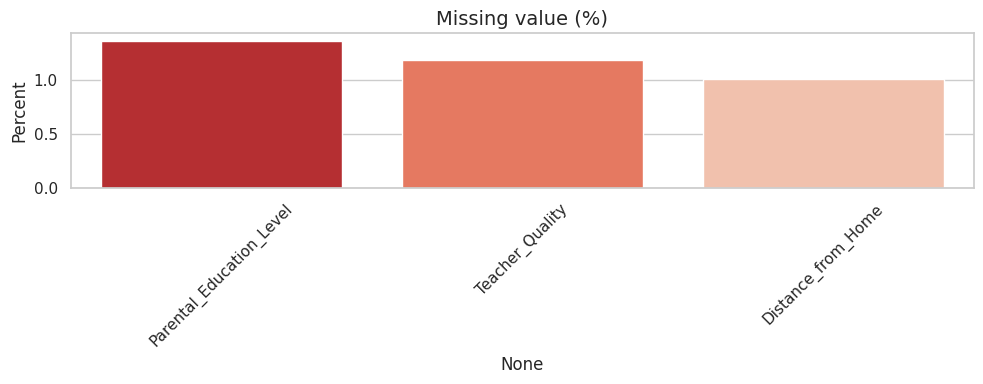

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

if missing_df.empty:
    print('No Missing Value!')
else:
    display(missing_df)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y='Percent', data=missing_df, palette='Reds_r')
    plt.title('Missing value (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Hedef Değişken Analizi: Exam_Score

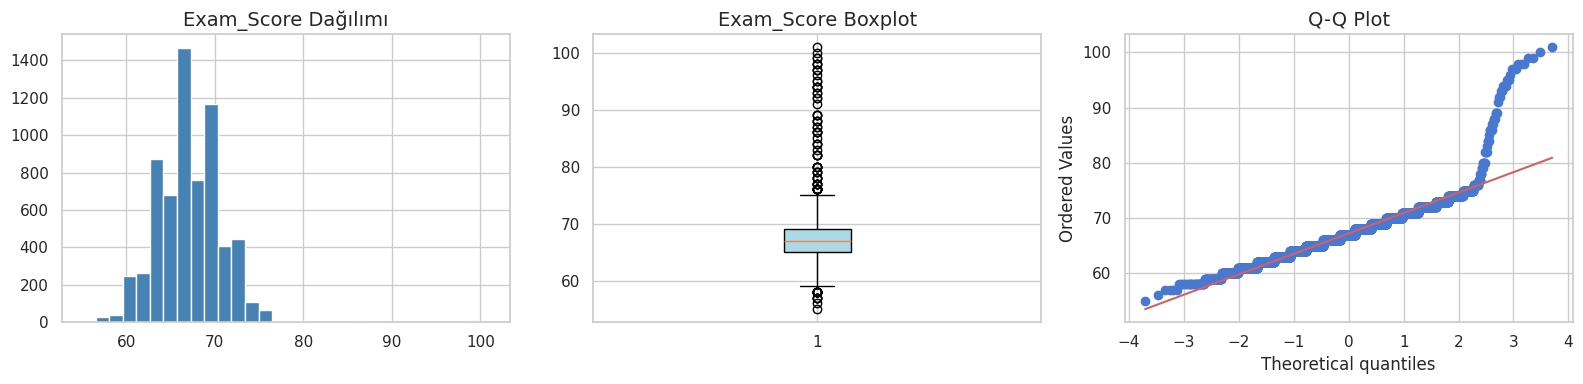

Skewness : 1.645
Kurtosis : 10.575
Mean     : 67.24
Std      : 3.89


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Exam_Score Dağılımı')

# Boxplot
axes[1].boxplot(df['Exam_Score'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Exam_Score Boxplot')

# QQ Plot
stats.probplot(df['Exam_Score'].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Skewness : {df['Exam_Score'].skew():.3f}")
print(f"Kurtosis : {df['Exam_Score'].kurt():.3f}")
print(f"Mean     : {df['Exam_Score'].mean():.2f}")
print(f"Std      : {df['Exam_Score'].std():.2f}")

## 5. Sayısal Değişkenlerin Dağılımı

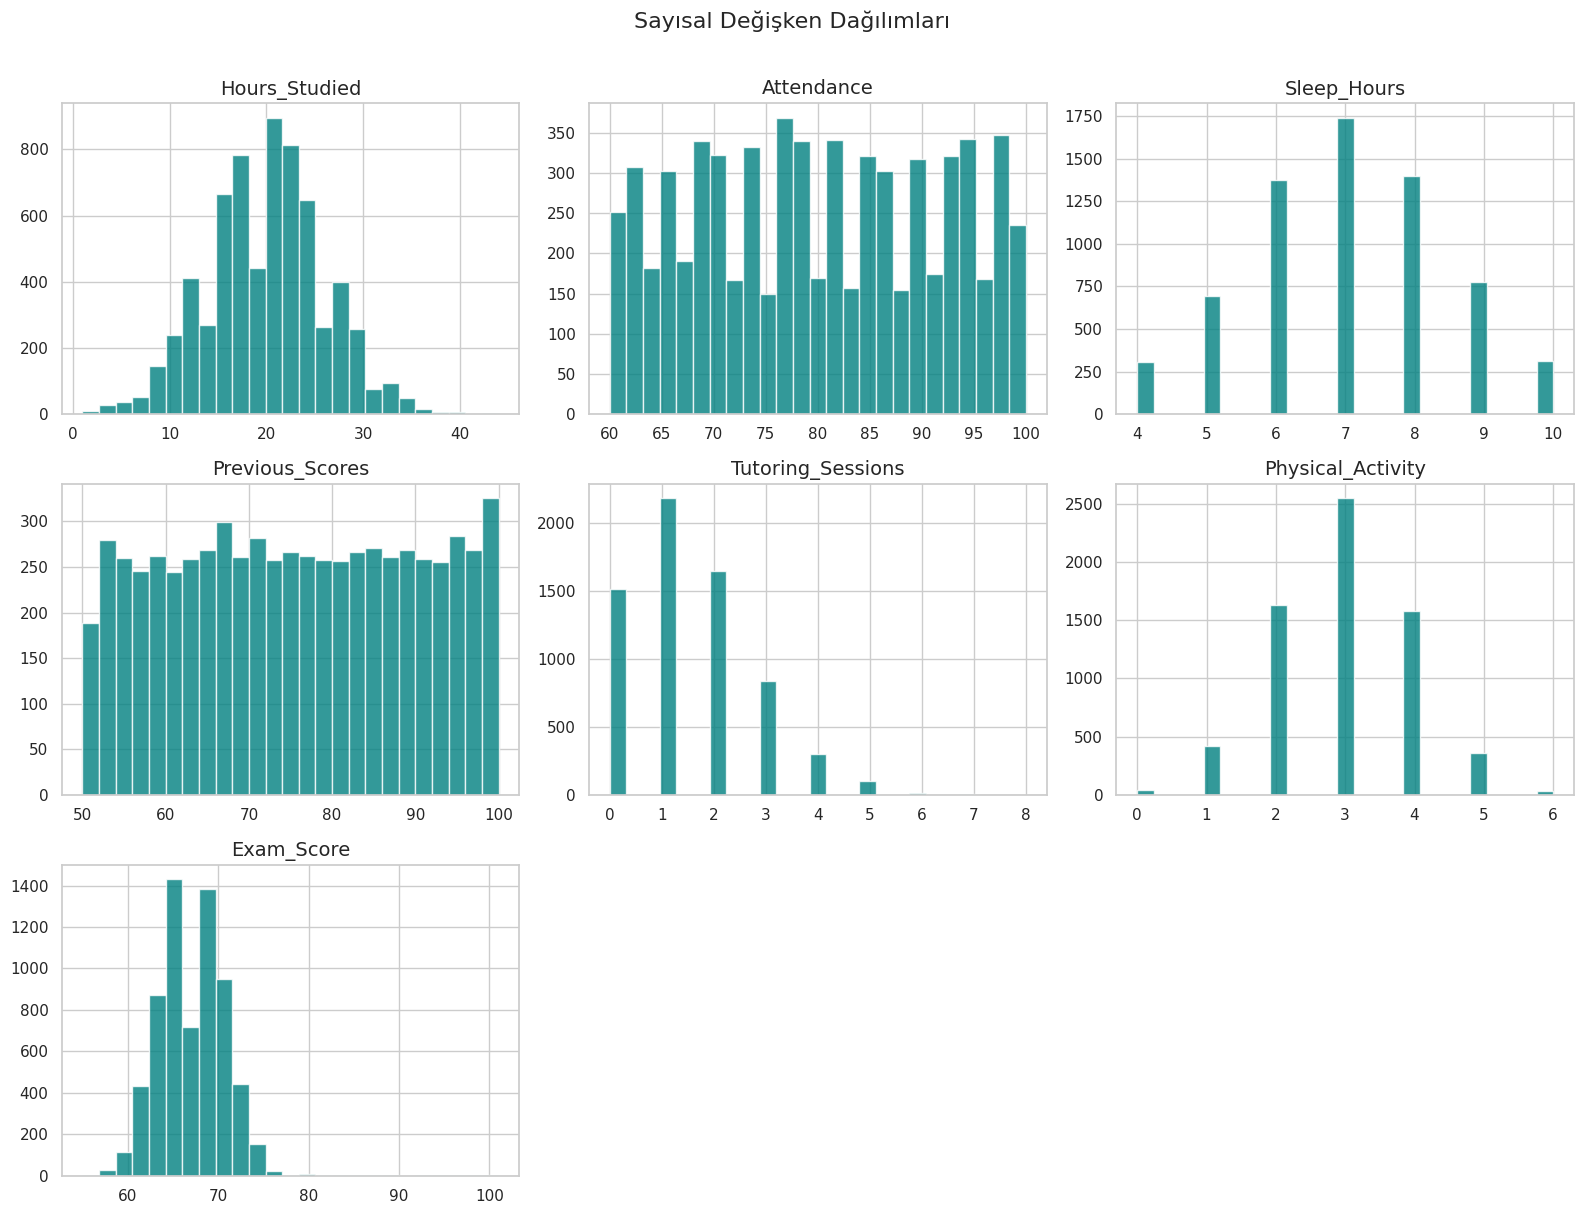

In [11]:
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sayısal Değişken Dağılımları', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Kategorik Değişkenlerin Dağılımı

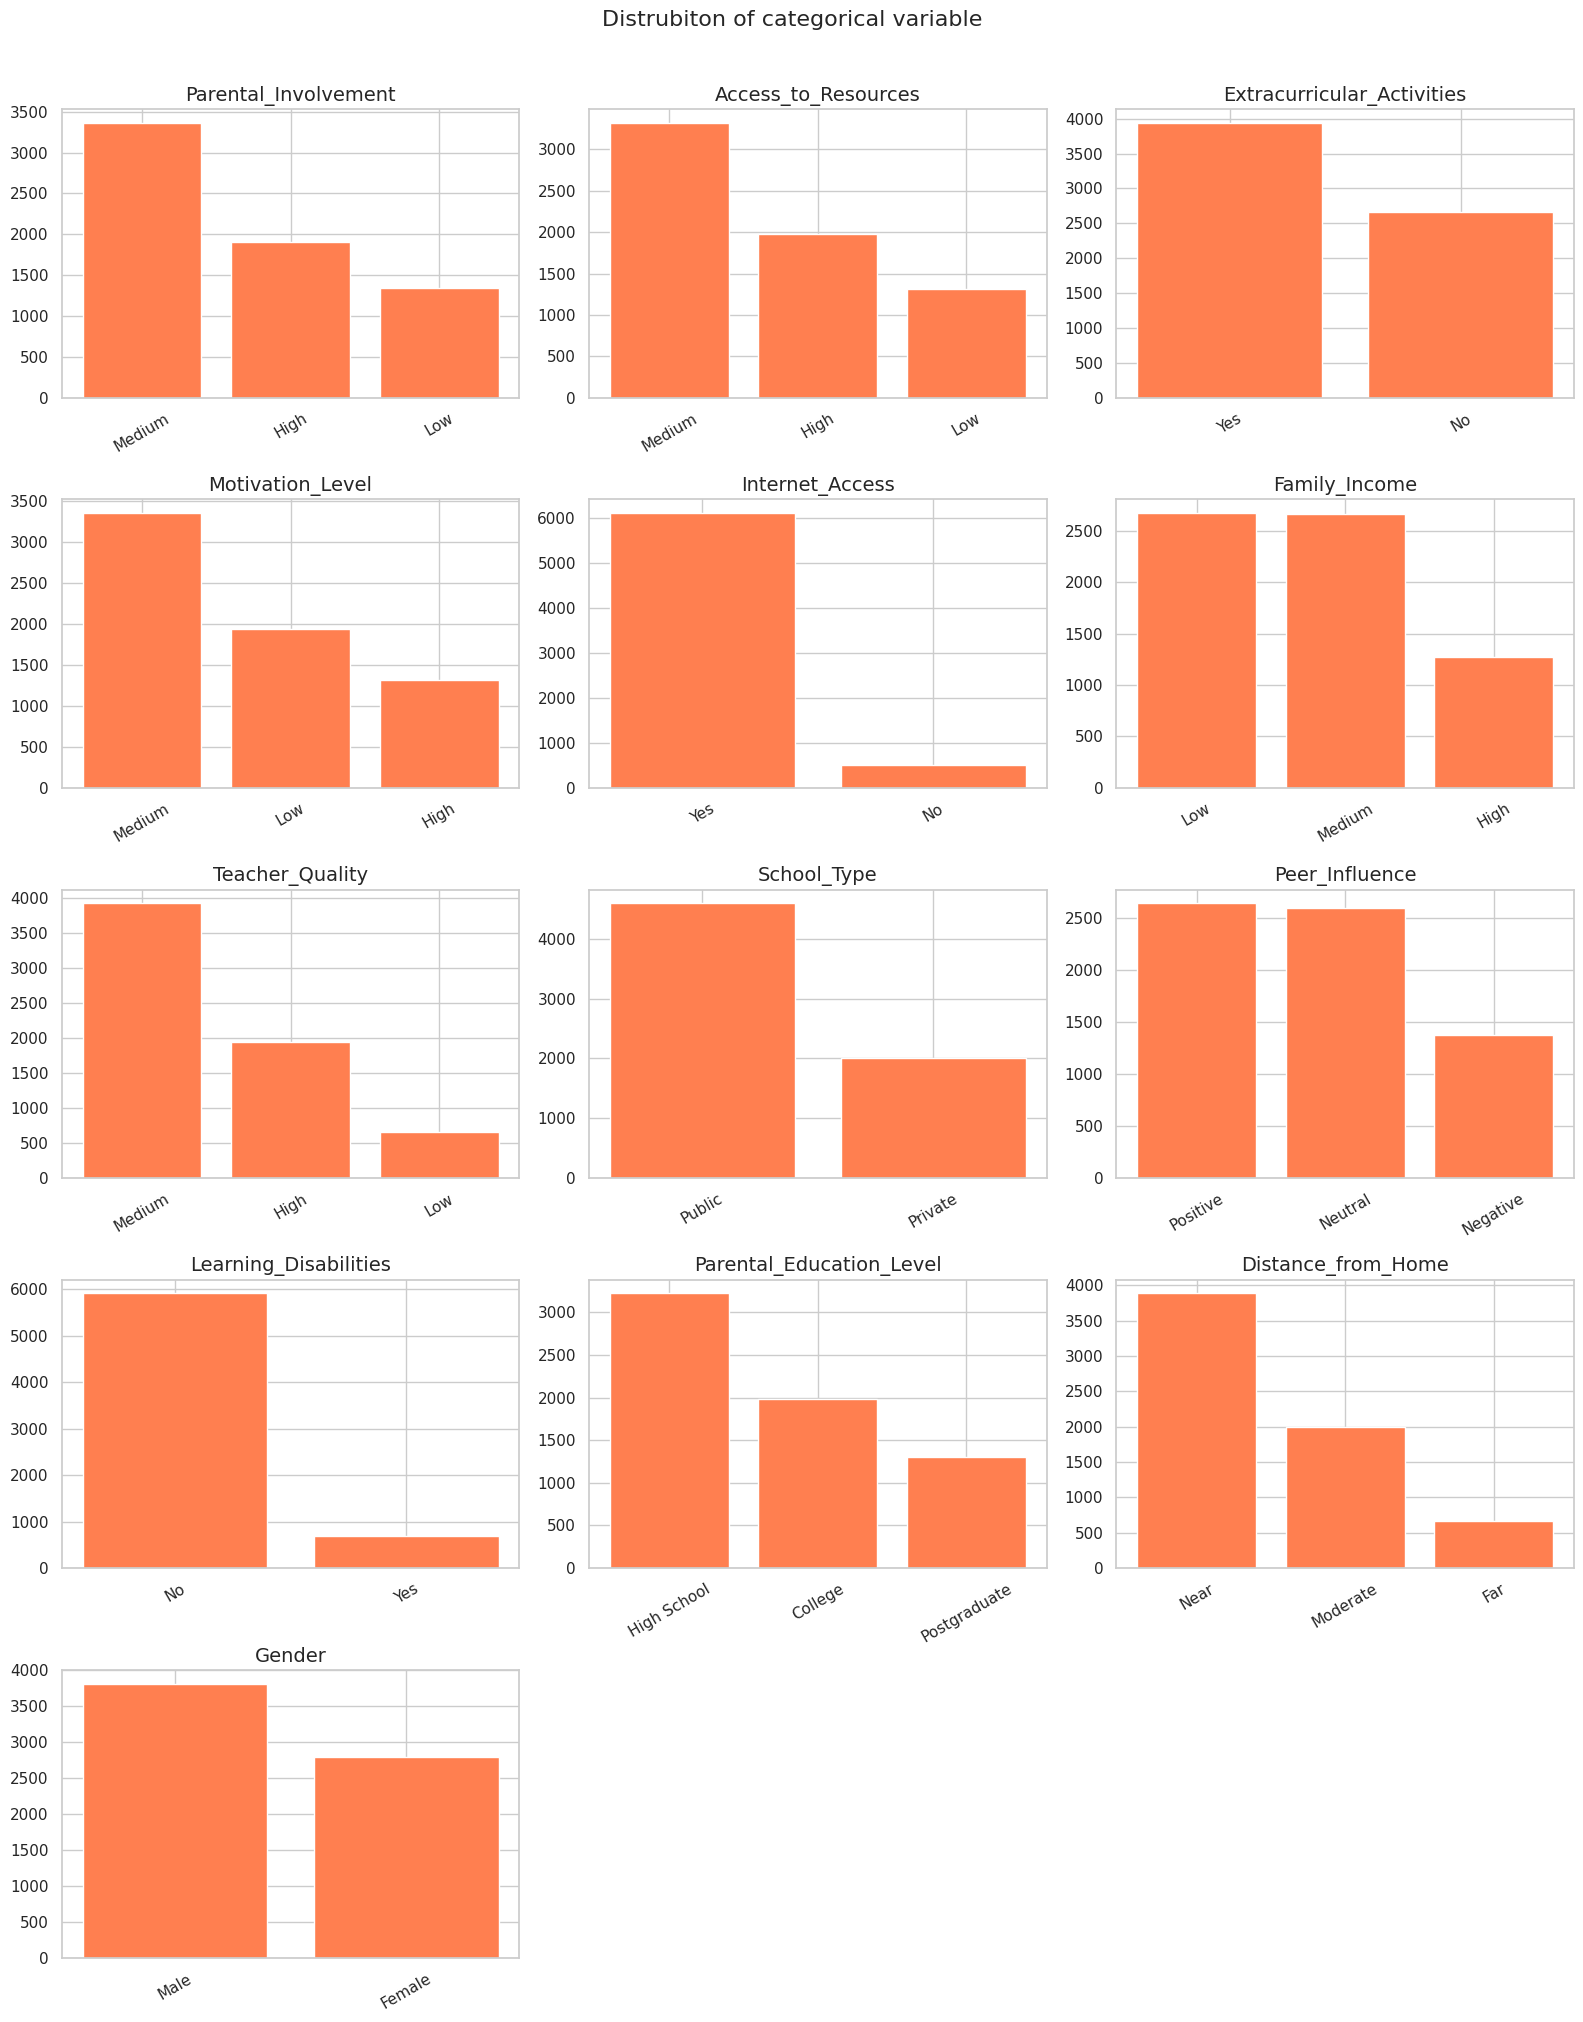

In [21]:
n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='coral', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distrubiton of categorical variable', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 7. Korelasyon Analizi

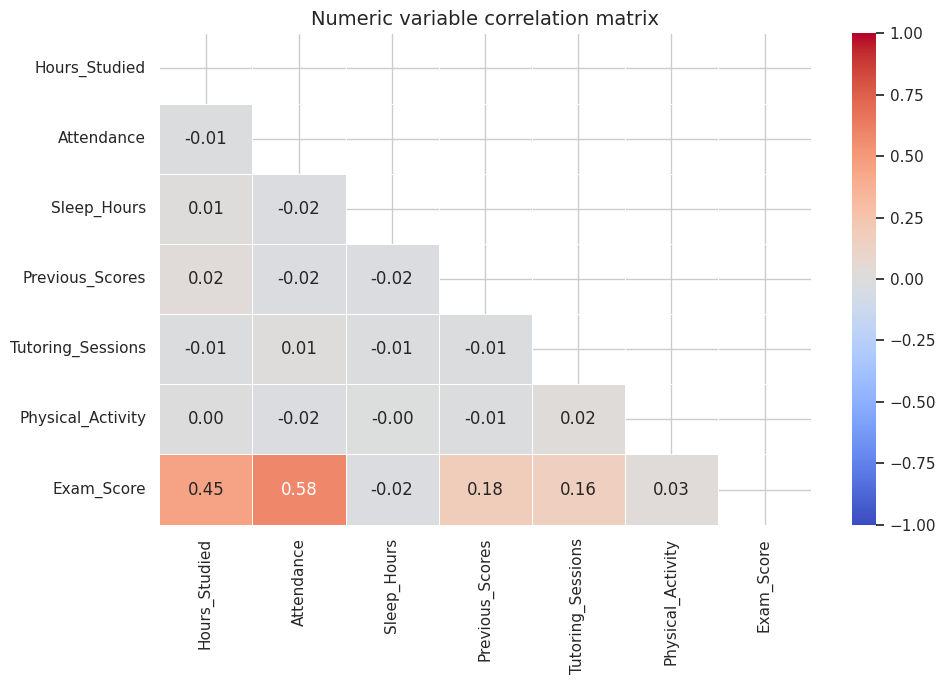

In [19]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Numeric variable correlation matrix')
plt.tight_layout()
plt.show()

In [14]:
# Exam_Score ile en yüksek korelasyonlar
target_corr = corr['Exam_Score'].drop('Exam_Score').sort_values(key=abs, ascending=False)
print('Exam_Score ile korelasyon:')
display(target_corr.to_frame())

Exam_Score ile korelasyon:


,Exam_Score
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


## 11. Preprocessing

In [15]:
df_clean = df.copy()
print(f'Başlangıç shape: {df_clean.shape}')

Başlangıç shape: (6607, 20)


In [16]:
# 11.1 Duplicate temizleme
dup = df_clean.duplicated().sum()
print(f'Duplicate satır: {dup}')
df_clean = df_clean.drop_duplicates()
print(f'Duplicate sonrası shape: {df_clean.shape}')

Duplicate satır: 0
Duplicate sonrası shape: (6607, 20)


In [17]:
# 11.2 Eksik değer doldurma
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'[NUM] {col} → median ile dolduruldu')

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        print(f'[CAT] {col} → mode ile dolduruldu')

print(f'\nKalan eksik değer: {df_clean.isnull().sum().sum()}')

[CAT] Teacher_Quality → mode ile dolduruldu
[CAT] Parental_Education_Level → mode ile dolduruldu
[CAT] Distance_from_Home → mode ile dolduruldu

Kalan eksik değer: 0


## 13. Temiz Dataset

In [ ]:
df_clean.to_csv('student_performance_cleaned.csv', index=False)
print(' student_performance_cleaned.csv saved.')
df_clean.head()